In [1]:
# Standard library
import math
import random

# Data manipulation
import numpy as np
import pandas as pd
import geopandas as gpd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.model_selection import (
    KFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.preprocessing import StandardScaler

# Explainability
import shap

# Custom utilities
import utils.cross_validation as cval

/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

### Plotting functions 

In [2]:
def SHAP_plots_v1(model_f, model_s, X_test_f, X_test_s, colour_f="#4b72f1", colour_s="#c88f8f"):
    
    explainer_f = shap.TreeExplainer(model_f)
    shap_values_f = explainer_f(X_test_f, approximate=True)
    
    explainer_s = shap.TreeExplainer(model_s)
    shap_values_s = explainer_s(X_test_s, approximate=True)

    fig, (ax_f, ax_s) = plt.subplots(1, 2, figsize=(14, 6))

    # ── Left: functional diversity ──
    plt.sca(ax_f)
    shap.plots.bar(shap_values_f.abs.mean(0), max_display=len(X_test_f.columns), show=False, ax=ax_f)
    for bar in ax_f.patches:
        bar.set_color(colour_f)
    ax_f.spines["right"].set_visible(True)
    ax_f.spines["left"].set_visible(True)

    # ── Right: species diversity — inverted ──
    plt.sca(ax_s)
    shap.plots.bar(shap_values_s.abs.mean(0), max_display=len(X_test_s.columns), show=False, ax=ax_s)
    for bar in ax_s.patches:
        bar.set_color(colour_s)
    ax_s.invert_xaxis()
    ax_s.yaxis.set_label_position("right")
    ax_s.yaxis.tick_right()
    ax_s.spines["right"].set_visible(True)
    ax_s.spines["left"].set_visible(True)
    for text in ax_s.texts:
        x, y = text.get_position()
        text.set_position((x + 0.03, y))

    # ── Align x axes ──
    max_val = max(ax_f.get_xlim()[1], ax_s.get_xlim()[0])  # ax_s is inverted so take [0]
    ax_f.set_xlim(0, max_val)
    ax_s.set_xlim(max_val, 0)  # inverted

    plt.tight_layout()
    plt.show()

    shap_df_f = pd.DataFrame(shap_values_f.values, columns=X_test_f.columns, index=X_test_f.index)
    shap_df_s = pd.DataFrame(shap_values_s.values, columns=X_test_s.columns, index=X_test_s.index)

    return shap_df_f, explainer_f, shap_df_s, explainer_s

def SHAP_plots(model_f, model_s, X_test_f, X_test_s,
               display_features_f, display_features_s,
               sum_features_f, sum_features_s,
               sum_label_f="Summed FD", sum_label_s="Summed SD",
               colour_f="#4b72f1", colour_s="#c88f8f"):

    explainer_f = shap.TreeExplainer(model_f)
    shap_values_f = explainer_f(X_test_f, approximate=True)
    explainer_s = shap.TreeExplainer(model_s)
    shap_values_s = explainer_s(X_test_s, approximate=True)

    shap_df_f = pd.DataFrame(shap_values_f.values, columns=X_test_f.columns, index=X_test_f.index)
    shap_df_s = pd.DataFrame(shap_values_s.values, columns=X_test_s.columns, index=X_test_s.index)

    # ── Sum specified features into one row ──
    def build_plot_df(shap_df, display_features, sum_features, sum_label):
        mean_abs = shap_df.abs().mean()
        plot_vals = mean_abs[display_features].to_dict()
        plot_vals[sum_label] = shap_df[sum_features].abs().sum(axis=1).mean()
        return pd.Series(plot_vals).sort_values(ascending=True)

    plot_f = build_plot_df(shap_df_f, display_features_f, sum_features_f, sum_label_f)
    plot_s = build_plot_df(shap_df_s, display_features_s, sum_features_s, sum_label_s)

    max_val = max(plot_f.max(), plot_s.max())

    fig, (ax_f, ax_s) = plt.subplots(1, 2, figsize=(14, 6))

    # ── Left: functional diversity ──
    ax_f.barh(plot_f.index, plot_f.values, color=colour_f)
    ax_f.set_xlim(0, max_val * 1.1)
    ax_f.spines[["right", "top"]].set_visible(False)
    ax_f.set_xlabel("mean |SHAP|")

    # ── Right: species diversity — inverted ──
    ax_s.barh(plot_s.index, plot_s.values, color=colour_s)
    ax_s.invert_xaxis()
    ax_s.yaxis.set_label_position("right")
    ax_s.yaxis.tick_right()
    ax_s.set_xlim(max_val * 1.1, 0)
    ax_s.spines[["left", "top"]].set_visible(False)
    ax_s.set_xlabel("mean |SHAP|")

    plt.tight_layout()
    plt.show()

    return shap_df_f, explainer_f, shap_df_s, explainer_s

def plot_pdp(div_f, div_s, fd_model, sd_model, fX_test, sX_test, name="pdp_plot.png"):

    paired_vars = list(zip(div_f, div_s))

    colors_f = "#09513A"
    colors_s = "#e39579"

    # 2 rows x 3 cols
    fig, axes = plt.subplots(1, 2, figsize=(8, 2))
    axes_flat = axes.flatten()  # flatten to iterate easily
    fig.subplots_adjust(hspace=0.6)  # increase from default ~0.2
    fig.subplots_adjust(wspace=0.4)  # increase space between plots

    plt.rcParams.update({'font.size': 8}) 
    for ax, (f_var, s_var) in zip(axes_flat, paired_vars):

        pd_f = partial_dependence(fd_model, fX_test, features=[f_var], grid_resolution=200,)
        pd_s = partial_dependence(sd_model, sX_test, features=[s_var], grid_resolution=200)

        x_f = pd_f["grid_values"][0]
        x_s = pd_s["grid_values"][0]
        y_f = pd_f["average"][0]
        y_s = pd_s["average"][0]

        # ── Bottom x-axis: species diversity ──
        ax.plot(x_s, y_s, color=colors_s, linewidth=2, linestyle="--")
        ax.set_xlabel(s_var)
        ax.tick_params(axis="x")

        # ── Top x-axis: functional diversity ──
        ax_top = ax.twiny()
        ax_top.plot(x_f, y_f, color=colors_f, linewidth=2)
        ax_top.set_xlabel(f_var)
        ax_top.tick_params(axis="x")

        # y label only on leftmost column
        ax.set_ylabel("Influence on Ecosystem Stability" if ax == axes[0] else "")
        ax.spines[["right"]].set_visible(False)
        ax_top.spines[["right"]].set_visible(False)

    # legend_elements = [
    #     Line2D([0], [0], color=colors_f, linewidth=2, label='Functional Diversity'),
    #     Line2D([0], [0], color=colors_s, linewidth=2, linestyle='--', label='Species Diversity')
    # ]
    # fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.25))
    fig.savefig(name, dpi=150, bbox_inches="tight")
        
def shap_beeswarm(model, X, omit_cols=None):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X, approximate=True)

    if isinstance(shap_values, list):
        sv = shap_values[0]
    else:
        sv = shap_values

    if omit_cols:
        all_features = sv.feature_names
        keep_idx     = [i for i, f in enumerate(all_features) if f not in omit_cols]

        sv = shap.Explanation(
            values        = sv.values[:, keep_idx],
            base_values   = sv.base_values,
            data          = sv.data[:, keep_idx],
            feature_names = [all_features[i] for i in keep_idx]
        )

    shap.plots.beeswarm(sv, max_display=sv.shape[1])


### Evaluation functions 

In [ ]:
biome_mapping = {
        0: 'Boreal and Tundra forests',
        1: 'Flooded grasslands',
        2: 'Mangroves',
        3: 'Mediterranean woodlands',
        4: 'Temperate broadleaf forests',
        5: 'Temperate conifer forests',
        6: 'Temperate grasslands',
        7: 'Tropical',
        8: 'Tropical',
        9: 'Tropical',
        10: 'Tropical',
        11: 'Boreal and Tundra forests',
        12: 'Xeric shrublands',
        13: np.nan
    }

def quick_eval(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    r2  = r2_score(y_test, y_pred, multioutput='raw_values')

    y_test = np.array(y_test)
    y_pred = np.array(y_pred)
    n_outputs = y_test.shape[1] if y_test.ndim > 1 else 1

    fig, axes = plt.subplots(1, n_outputs, figsize=(5 * n_outputs, 4), squeeze=False)

    for i in range(n_outputs):
        ax = axes[0, i]
        y_t = y_test[:, i] if n_outputs > 1 else y_test
        y_p = y_pred[:, i] if n_outputs > 1 else y_pred

        ax.hexbin(y_t, y_p, gridsize=40, cmap='YlOrRd', mincnt=1)
        fig.colorbar(ax.collections[0], ax=ax, label='Count')

        min_val = min(y_t.min(), y_p.min())
        max_val = max(y_t.max(), y_p.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Perfect fit')

        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Output {i+1} | MAE: {mae[i]:.3f} | R²: {r2[i]:.3f}')
        ax.legend()

    plt.tight_layout()
    plt.show()

    return mae, r2


def quick_eval_combined(models_info, figsize_per_plot=(5, 4)):
    type_styles = {
        'Functional Diversity': 'YlOrRd',
        'Species Diversity':    'YlGnBu',
    }

    all_results = []
    for info in models_info:
        y_pred = info['model'].predict(info['X_test'])
        y_test = np.array(info['y_test'])
        y_pred = np.array(y_pred)
        mae    = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
        r2     = r2_score(y_test, y_pred, multioutput='raw_values')
        n_out  = y_test.shape[1] if y_test.ndim > 1 else 1
        all_results.append((info, y_test, y_pred, mae, r2, n_out))

    # Flatten into individual (model, output_index) panels
    panels = []
    for result in all_results:
        info, y_test, y_pred, mae, r2, n_out = result
        for col in range(n_out):
            panels.append((info, y_test, y_pred, mae, r2, col, n_out))

    n_cols = 2
    n_rows = math.ceil(len(panels) / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_rows),
        squeeze=False
    )

    for idx, (info, y_test, y_pred, mae, r2, col, n_out) in enumerate(panels):
        ax    = axes[idx // n_cols, idx % n_cols]
        cmap  = type_styles.get(info['type'], 'Greys')
        label = f"{info['biome']} — {info['type']}"

        y_t = y_test[:, col] if n_out > 1 else y_test
        y_p = y_pred[:, col] if n_out > 1 else y_pred

        hb = ax.hexbin(y_t, y_p, gridsize=40, cmap=cmap, mincnt=1)
        fig.colorbar(hb, ax=ax, label='Count')

        min_val = min(y_t.min(), y_p.min())
        max_val = max(y_t.max(), y_p.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5)

        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{label}\nOutput {col+1} | MAE: {mae[col]:.3f} | R²: {r2[col]:.3f}')

    # Hide any unused axes
    for idx in range(len(panels), n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].axis('off')

    plt.suptitle('Model Evaluation by Biome & Diversity Type', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    
def train_test_split(df, random_key, test_size):
    sub_df = df.drop(columns=['BHAGE', 'managed',
        'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
        'lon_bin', 'lat_bin', 'TPA_UNADJ', 'WSCI'])

    sets=list(sub_df['ECO_NAME'].unique())

    random.seed(random_key)
    test_set = random.sample(sets, int(test_size * len(sets)))
    test = sub_df[sub_df["ECO_NAME"].isin(test_set)]
    train = sub_df[~sub_df["ECO_NAME"].isin(test_set)]

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test

def train_test_split_v2(df, random_key, test_size):
    sub_df = df.drop(columns=[ 'managed',
        'ownership', 'biome', 'geometry', 'index_right', 'lat', 'lon', 'DIA',
        'lon_bin', 'lat_bin', 'TPA_UNADJ', 'WSCI', 'transformed npp', 'mean'])

    sets=list(set(sub_df['ECO_NAME']))
 

    random.seed(random_key)
    test_set = random.sample(sets, int(test_size * len(sets)))
    test = sub_df[sub_df["ECO_NAME"].isin(test_set)]
    train = sub_df[~sub_df["ECO_NAME"].isin(test_set)]

    y=['residuals'] 
    X_train=train.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_train = train['residuals'].values

    X_test= test.drop(columns=y+['PID', 'spatial_group', 'ECO_NAME'])
    y_test = test['residuals'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test

def data_processing_v2(df, biome_mapping):
     
    # df = df[df['biome'].isin([4,5,6,12])]

    df["biome"] = df["biome"].replace(biome_mapping)

    df=cval.assign_spatial_groups(df, grid_size=1.0)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"  # WGS84
    )

    joined = gpd.sjoin(gdf, ecoregions, how="left", predicate="within")

    biome_dfs = {k: v for k, v in joined.groupby('biome')}
    return biome_dfs

In [39]:

def train_rf_cv(X, y, n_splits=5, rf_params=None):
    if rf_params is None:
        rf_params = {
            'n_estimators': 200,
            'max_depth': None,
            'min_samples_leaf': 2,
            'n_jobs': -1,
            'random_state': 42
        }

    # Fix: reset index to avoid positional/label index mismatch
    X = np.array(X)
    y = np.array(y)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    model = RandomForestRegressor(**rf_params)

    fold_mae, fold_r2 = [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]  # use .iloc
        y_train, y_val = y[train_idx], y[val_idx]  # use .iloc

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred, multioutput='raw_values')
        r2  = r2_score(y_val, y_pred, multioutput='raw_values')

        fold_mae.append(mae)
        fold_r2.append(r2)

        # print(f"Fold {fold} | MAE: {mae.round(3)} | R²: {r2.round(3)}")

    fold_mae = np.array(fold_mae)
    fold_r2  = np.array(fold_r2)

    # print("\n--- Cross-Validation Summary ---")
    # print(f"MAE  — mean: {fold_mae.mean(axis=0).round(3)}, std: {fold_mae.std(axis=0).round(3)}")
    # print(f"R²   — mean: {fold_r2.mean(axis=0).round(3)},  std: {fold_r2.std(axis=0).round(3)}")

    # final_model = RandomForestRegressor(**rf_params)
    # final_model.fit(X, y)
    # print("\nFinal model trained on full dataset.")

    return model, fold_mae, fold_r2

## Analysis

In [31]:

fd_df= pd.read_csv("data/final/fd_df.csv")
sd_df = pd.read_csv("data/final/sd_df.csv")

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]

fd_df = fd_df.loc[:, ~fd_df.columns.str.contains(r'\.1')]
sd_df = sd_df.loc[:, ~sd_df.columns.str.contains(r'\.1')]

fd_df.drop(columns=['Mean Pairwise D'], inplace=True)
fd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude

sd_df.dropna(subset=['TPA_UNADJ'], inplace=True) # Maybe exclude
# sd_df = sd_df[sd_df["WSCI"] >= -1000]
# fd_df = fd_df[fd_df["WSCI"] >= -1000]


sd_df.columns = sd_df.columns.str.replace('_x$', '', regex=True)
sd_df.columns = sd_df.columns.str.replace('_y$', '', regex=True)

sd_df = sd_df.loc[:, ~sd_df.columns.duplicated()]

shared_pids = set(sd_df["PID"]).intersection(fd_df["PID"])

# Filter both dataframes to only shared PIDs
sd_df = sd_df[sd_df["PID"].isin(shared_pids)]
fd_df = fd_df[fd_df["PID"].isin(shared_pids)]

#Preprocessing the data for Random forest regression

fbiome_dfs= data_processing_v2(fd_df, biome_mapping)
sbiome_dfs =data_processing_v2(sd_df, biome_mapping)

In [6]:
fd_df['biome'].value_counts()

biome
Temperate broadleaf forests    31227
Temperate conifer forests      10188
Temperate grasslands            8914
Xeric shrublands                 991
Boreal and Tundra forests        239
Tropical                         159
Flooded grasslands                28
Mediterranean woodlands           24
Mangroves                         11
Name: count, dtype: int64

In [ ]:
biomes_list=['Temperate broadleaf forests','Temperate conifer forests',
            'Temperate grasslands', 'Boreal and Tundra forests' ]

# biomes_list=['Boreal and Tundra forests']

for biome in biomes_list:
    print(f"Biome: {biome}")
    fX_train, fy_train, fX_test, fy_test = train_test_split(fbiome_dfs[biome], random_key=27, test_size=0.4)
    sX_train, sy_train, sX_test, sy_test = train_test_split(sbiome_dfs[biome], random_key=27, test_size=0.4)
    
    print('Functional ')
    fmodel, mae, r2 = train_rf_cv(fX_train, fy_train, n_splits=10)
    smodel, mae_s, r2_s = train_rf_cv(sX_train, sy_train, n_splits=10)
    models_info = [
    {'model': fmodel, 'X_test': fX_test, 'y_test': fy_test, 'biome': biome, 'type': 'Functional Diversity'},
    {'model': smodel, 'X_test': sX_test, 'y_test': sy_test, 'biome': biome, 'type': 'Species Diversity'},
    ]

    quick_eval_combined(models_info)

    # print(f"Functional Diversity - MAE: {fd_mae}, R²: {fd_r2}")
    # print(f"Species Diversity - MAE: {sd_mae}, R²: {sd_r2}")

    diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
    diversity_vars_s = ["Simpson's Index", 'Shannon Diversity']
    plot_name = f"results/pdp_{biome.replace(' ', '_')}.png"
    plot_pdp(diversity_vars_f, diversity_vars_s, fd_reg, sd_reg, fX_test, sX_test, plot_name)


Biome: Temperate broadleaf forests
test set: ['East Central Texas forests', 'Mississippi lowland forests', 'Central Tallgrass prairie', 'New England-Acadian forests', 'Southern Great Lakes forests', 'Appalachian mixed mesophytic forests', 'Allegheny Highlands forests', 'Appalachian Piedmont forests']
test set: ['East Central Texas forests', 'Mississippi lowland forests', 'Central Tallgrass prairie', 'New England-Acadian forests', 'Southern Great Lakes forests', 'Appalachian mixed mesophytic forests', 'Allegheny Highlands forests', 'Appalachian Piedmont forests']
Functional 


In [8]:
fsub_df=fbiome_dfs['Temperate broadleaf forests']
ssub_df=sbiome_dfs['Temperate broadleaf forests']

In [9]:
common_cols = ssub_df.columns.intersection(fsub_df.columns).difference(['PID'])

merged_df = fsub_df.merge(
    ssub_df.drop(columns=common_cols),
    on='PID'
)

In [10]:
X_train, y_train, X_test, y_test = train_test_split(merged_df, 42, test_size=0.4)

In [11]:

model=RandomForestRegressor(
    random_state=42,
    n_jobs=4
)

model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


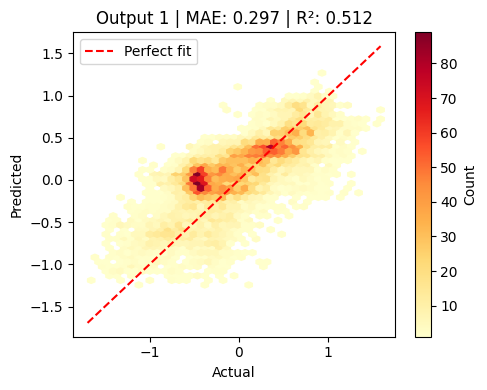

(array([0.29703174]), array([0.51178103]))

In [12]:
quick_eval(model, X_test, y_test)

In [13]:
X_test = X_test.rename(columns={'CHELSA_BIO_Annual_Mean_Temperature': 'Annual Temp', 'CHELSA_BIO_Annual_Precipitation': 'Annual Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality': 'Precipitation Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km': 'Soil Moisture',
       'SG_SOC_Content_015cm': 'SOC Content', 'EsaCci_BurntAreasProbability': 'Burnt Areas Probability',
       'EarthEnvTopoMed_Elevation': 'Elevation', 'EarthEnvTopoMed_Slope': 'Slope',
       'SG_Depth_to_bedrock': 'Depth to Bedrock', 'EarthEnvTopoMed_Northness': 'Northness'})

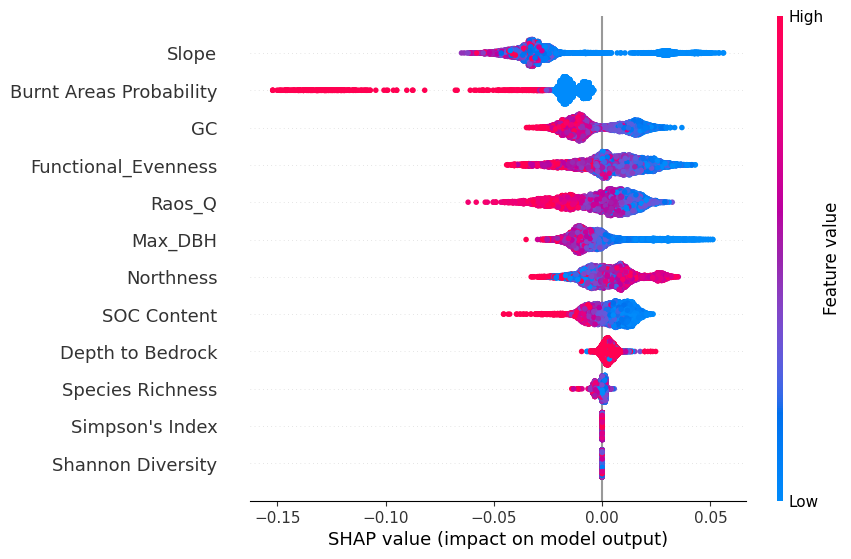

In [14]:
shap_beeswarm(fmodel, X_test, omit_cols=['Annual Temp', 'Annual Precipitation', 'Precipitation Seasonality', 'Soil Moisture', 'Elevation'])

In [15]:
fX_train, fy_train, fX_test, fy_test = train_test_split(fsub_df, 12, 0.4)
sX_train, sy_train, sX_test, sy_test = train_test_split(ssub_df, 12, 0.4)

# f_cols = ["Raos_Q", "Functional_Evenness", "Species Richness", "WSCI"]  # replace with your columns
# s_cols = ["Simpson's Index", 'Shannon Diversity', 'Species Richness', 'WSCI']  # replace with your columns

# fX_test = fX_test[f_cols]
# fX_train = fX_train[f_cols]
# sX_test = sX_test[s_cols]
# sX_train= sX_train[s_cols]

In [16]:

fd_reg=RandomForestRegressor(
    random_state=42,
    n_jobs=4
)

sd_reg=RandomForestRegressor(
    random_state=42,
    n_jobs=4
)

sd_reg.fit(sX_train, sy_train)
fd_reg.fit(fX_train, fy_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


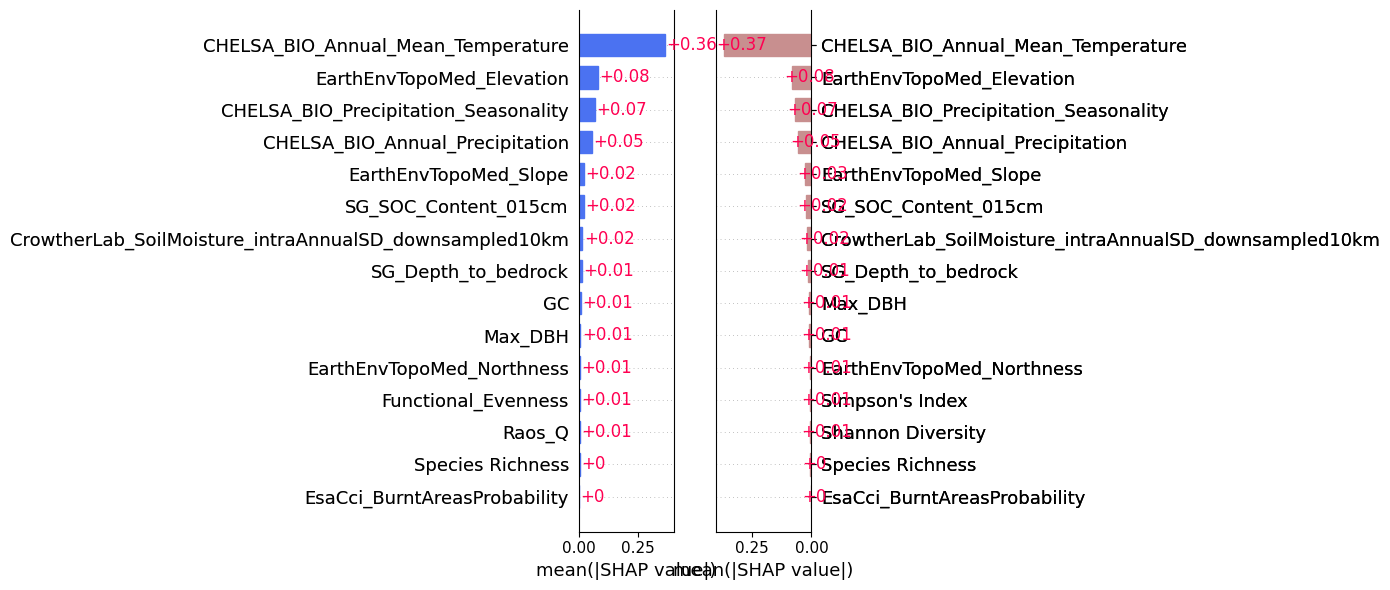

In [17]:
from sklearn.inspection import partial_dependence
import matplotlib.pyplot as plt


fshap_df, fexplainer, sshap_df, sexplainer = SHAP_plots_v1(
    fd_reg, sd_reg, fX_test, sX_test
)


In [18]:
fX_test = fX_test.rename(columns={'CHELSA_BIO_Annual_Mean_Temperature': 'Annual Temp', 'CHELSA_BIO_Annual_Precipitation': 'Annual Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality': 'Precipitation Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km': 'Soil Moisture',
       'SG_SOC_Content_015cm': 'SOC Content', 'EsaCci_BurntAreasProbability': 'Burnt Areas Probability',
       'EarthEnvTopoMed_Elevation': 'Elevation', 'EarthEnvTopoMed_Slope': 'Slope',
       'SG_Depth_to_bedrock': 'Depth to Bedrock', 'EarthEnvTopoMed_Northness': 'Northness'})

sX_test = sX_test.rename(columns={'CHELSA_BIO_Annual_Mean_Temperature': 'Annual Temp', 'CHELSA_BIO_Annual_Precipitation': 'Annual Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality': 'Precipitation Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km': 'Soil Moisture',
       'SG_SOC_Content_015cm': 'SOC Content', 'EsaCci_BurntAreasProbability': 'Burnt Areas Probability',
       'EarthEnvTopoMed_Elevation': 'Elevation', 'EarthEnvTopoMed_Slope': 'Slope',
       'SG_Depth_to_bedrock': 'Depth to Bedrock', 'EarthEnvTopoMed_Northness': 'Northness'})

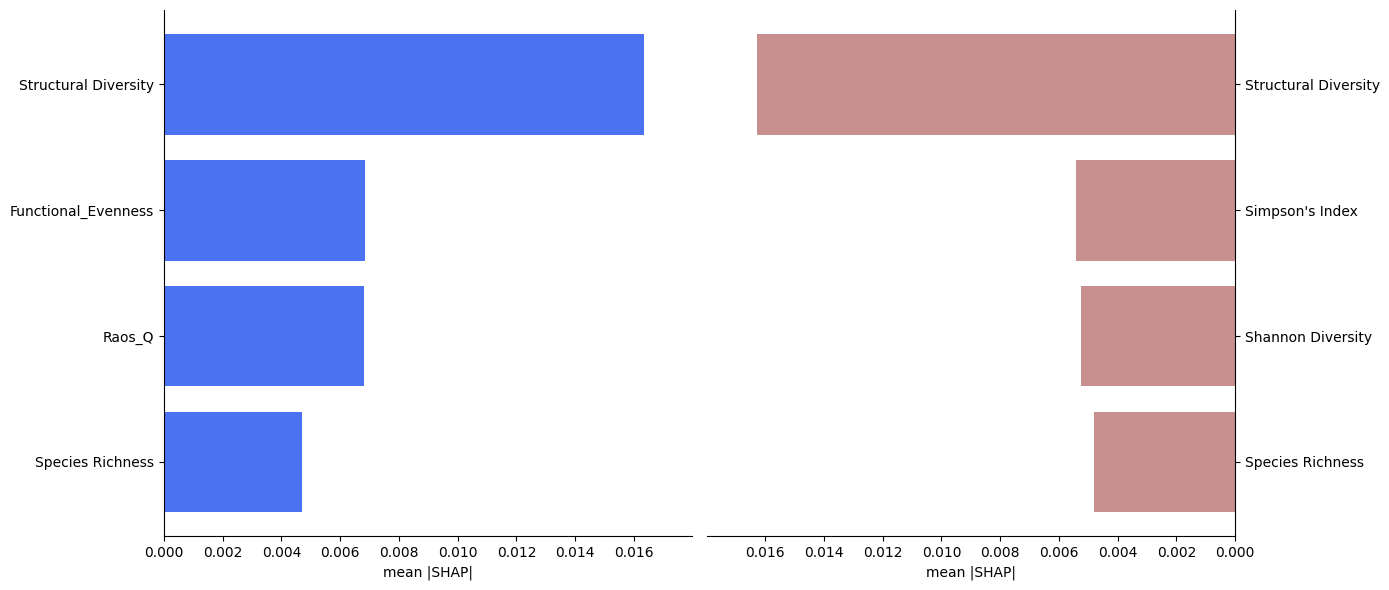

In [19]:
shap_df_f, explainer_f, shap_df_s, explainer_s = SHAP_plots(
    model_f=fd_reg,
    model_s=sd_reg,
    X_test_f=fX_test,
    X_test_s=sX_test,
    display_features_f=['Raos_Q', 'Functional_Evenness', 'Species Richness'],
    display_features_s=['Species Richness','Shannon Diversity', "Simpson's Index"],
    sum_features_f=['GC', 'Max_DBH'],
    sum_features_s=['GC', 'Max_DBH'],
    sum_label_f="Structural Diversity",
    sum_label_s="Structural Diversity"
)

### Linear Regress

In [20]:
fsub_df=fbiome_dfs['Temperate broadleaf forests']
ssub_df=sbiome_dfs['Temperate broadleaf forests']

In [21]:
common_cols = ssub_df.columns.intersection(fsub_df.columns).difference(['PID'])

merged_df = fsub_df.merge(
    ssub_df.drop(columns=common_cols),
    on='PID'
)

In [22]:
npp_df1=pd.read_csv('data/processed/npp_volatility.csv')

merged_df = merged_df.merge(npp_df1[['PID','mean']], on='PID')

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import linear_model

def plot_linear_regression(df, col_a, col_b):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy import stats

    x = df[col_a].values
    y = df[col_b].values

    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]

    slope, intercept, r, p, se = stats.linregress(x, y)

    y_pred = slope * x + intercept
    residuals = y - y_pred

    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept

    fig, ax = plt.subplots(figsize=(7, 6))

    # Heatmap-style scatter
    hb = ax.hexbin(
        x,
        y,
        gridsize=50,
        cmap='viridis',
        mincnt=1
    )

    # Regression line
    ax.plot(x_line, y_line, 'r-', lw=2)

    # Colorbar
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label('Count')

    ax.set_xlabel(col_a)
    ax.set_ylabel(col_b)

    ax.set_title(
        f'y = {slope:.3f}x + {intercept:.3f}\n'
        f'R² = {r**2:.3f}  |  p = {p:.3e}'
    )

    plt.tight_layout()
    plt.show()

    return slope, intercept, r**2, p, residuals

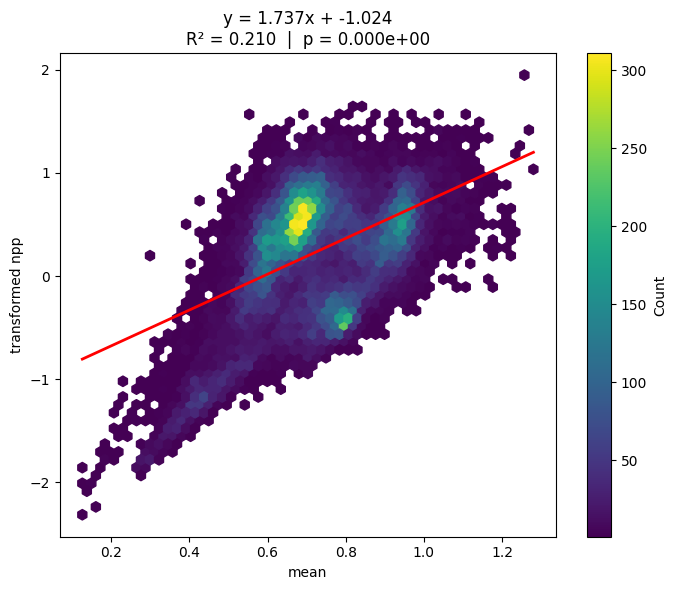

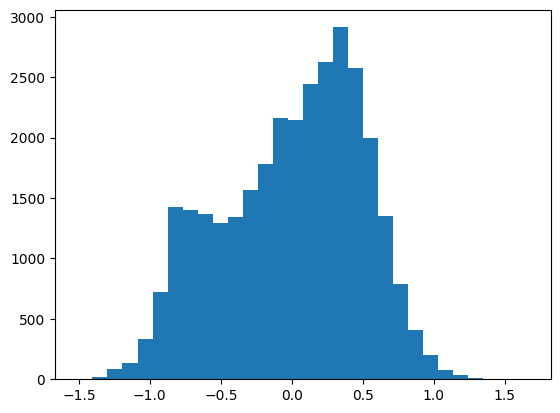

In [24]:
slope, intercept, r2, p, residuals = plot_linear_regression(merged_df, col_a='mean', col_b='transformed npp')

# Inspect residuals
plt.hist(residuals, bins=30)  # should be roughly normal
plt.show()

In [25]:
merged_df['residuals'] = pd.Series(residuals)
merged_df.drop(columns=['BHAGE'], inplace=True)
merged_df.dropna(subset=['CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km'], inplace=True) # Maybe exclude

X_train, y_train, X_test, y_test = train_test_split_v2(merged_df, 42, test_size=0.4)

regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:


# Predict on test set
y_pred = regr.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2: 0.3742788029937225
MAE: 0.3217010226438503
MSE: 0.1585593881175464
RMSE: 0.3981951633527791


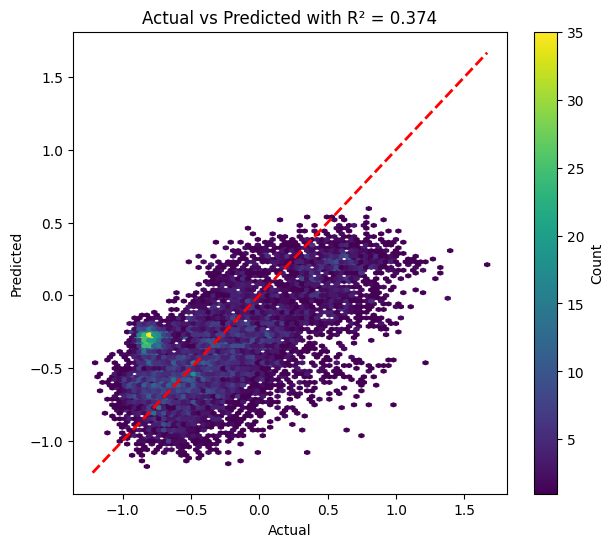

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = regr.predict(X_test)

# Hexbin heatmap
plt.figure(figsize=(7, 6))

hb = plt.hexbin(
    y_test,
    y_pred,
    gridsize=80,
    cmap='viridis',
    mincnt=1
)

# Colorbar
cb = plt.colorbar(hb)
cb.set_label('Count')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted with R² = {r2:.3f}")

plt.show()

In [28]:
fd_df.columns

Index(['PID', 'Raos_Q', 'Functional_Evenness',
       'CHELSA_BIO_Annual_Mean_Temperature', 'CHELSA_BIO_Annual_Precipitation',
       'CHELSA_BIO_Precipitation_Seasonality',
       'CrowtherLab_SoilMoisture_intraAnnualSD_downsampled10km',
       'SG_SOC_Content_015cm', 'EsaCci_BurntAreasProbability',
       'EarthEnvTopoMed_Elevation', 'EarthEnvTopoMed_Slope',
       'SG_Depth_to_bedrock', 'EarthEnvTopoMed_Northness', 'managed',
       'ownership', 'biome', 'Species Richness', 'transformed npp', 'lat',
       'lon', 'BHAGE', 'WSCI', 'TPA_UNADJ', 'DIA', 'GC', 'Max_DBH'],
      dtype='str')